In [1]:
!pip install -q yfinance pandas numpy matplotlib scikit-learn

In [2]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import yfinance as yf

from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

In [3]:
ticker = "BTC-USD"

df = yf.download(
    ticker,
    period="10y",
    interval="1d",
    auto_adjust=True,
    progress=False
)

# Flatten MultiIndex columns if necessary
if isinstance(df.columns, pd.MultiIndex):
    df.columns = df.columns.get_level_values(0)

df.head()

Price,Close,High,Low,Open,Volume
Date,,,,,
2016-07-06,677.330994,681.898010,670.418030,670.418030,134960992
2016-07-07,640.562012,682.432007,611.833984,678.090027,258091008
2016-07-08,666.523010,666.706970,636.466980,640.687988,141970000
2016-07-09,650.960022,666.383972,633.398987,666.383972,180536000
2016-07-10,649.359985,652.294006,641.263977,650.598999,102532000


In [4]:
print("Shape:", df.shape)

df.info()

df.describe()

Shape: (3653, 5)
<class 'pandas.DataFrame'>
DatetimeIndex: 3653 entries, 2016-07-06 to 2026-07-06
Data columns (total 5 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Close   3653 non-null   float64
 1   High    3653 non-null   float64
 2   Low     3653 non-null   float64
 3   Open    3653 non-null   float64
 4   Volume  3653 non-null   int64  
dtypes: float64(4), int64(1)
memory usage: 171.2 KB


Price,Close,High,Low,Open,Volume
count,3653.000000,3653.000000,3653.000000,3653.000000,3.653000e+03
mean,34019.856646,34673.851063,33289.238777,34004.248013,2.636404e+10
std,32706.622453,33240.507720,32130.980712,32708.572993,2.262579e+10
min,547.465027,573.359985,531.333984,548.656006,3.397780e+07
25%,7410.656738,7546.996582,7255.439941,7406.149902,8.428290e+09
50%,22362.679688,22673.820312,21632.394531,22354.144531,2.289989e+10
75%,57539.945312,58872.878906,56038.960938,57532.738281,3.770731e+10
max,124752.531250,126198.070312,123196.046875,124752.140625,3.509679e+11


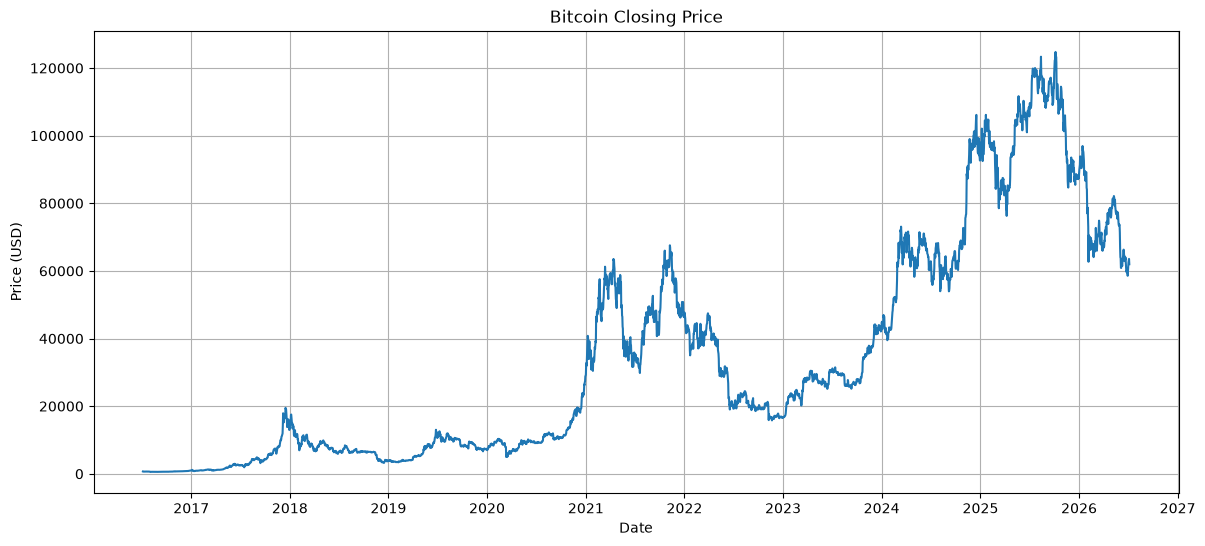

In [5]:
plt.figure(figsize=(14,6))
plt.plot(df["Close"])
plt.title("Bitcoin Closing Price")
plt.xlabel("Date")
plt.ylabel("Price (USD)")
plt.grid(True)
plt.show()

In [6]:
# Moving Averages
df["SMA10"] = df["Close"].rolling(10).mean()
df["SMA30"] = df["Close"].rolling(30).mean()

# Exponential Moving Average
df["EMA10"] = df["Close"].ewm(span=10).mean()

# RSI

delta = df["Close"].diff()

gain = delta.clip(lower=0).rolling(14).mean()
loss = (-delta.clip(upper=0)).rolling(14).mean()

rs = gain / loss

df["RSI"] = 100 - (100/(1+rs))

# Target = Next Day Close

df["Target"] = df["Close"].shift(-1)

df = df.dropna()

df.head()

Price,Close,High,Low,Open,Volume,SMA10,SMA30,EMA10,RSI,Target
Date,,,,,,,,,,
2016-08-04,578.289001,579.495972,565.776978,566.328979,125292000,619.627197,646.915637,608.017892,25.926173,575.043030
2016-08-05,575.043030,578.281006,569.981995,578.281006,66127900,611.953101,643.506038,602.010522,27.636517,587.778015
2016-08-06,587.778015,588.395996,569.468994,575.030029,80797296,605.295703,641.746572,599.418578,30.828739,592.690002
2016-08-07,592.690002,597.513000,586.815979,587.770996,82398400,599.061206,639.285472,598.193571,30.507574,591.054016
2016-08-08,591.054016,592.994019,588.046997,592.736023,61194100,592.467407,637.288605,596.894055,31.501572,587.801025


In [7]:
X = df.drop(columns=["Target"])
y = df["Target"]

print("Features Shape:", X.shape)
print("Target Shape:", y.shape)

Features Shape: (3623, 9)
Target Shape: (3623,)


In [8]:
split = int(len(df) * 0.80)

X_train = X.iloc[:split]
X_test = X.iloc[split:]

y_train = y.iloc[:split]
y_test = y.iloc[split:]

print(X_train.shape)
print(X_test.shape)

(2898, 9)
(725, 9)


In [9]:
model = Pipeline([
    (
        "imputer",
        SimpleImputer(strategy="median")
    ),
    (
        "model",
        RandomForestRegressor(
            n_estimators=300,
            random_state=42,
            n_jobs=-1
        )
    )
])

model.fit(X_train, y_train)

print("Model Training Completed!")

Model Training Completed!


In [10]:
predictions = model.predict(X_test)

predictions[:10]

array([56773.60914062, 57074.86869792, 58050.74688802, 61777.9165625 ,
       64721.17822917, 64106.9731901 , 64673.34316406, 64299.16236979,
       66244.51916667, 68107.30606771])

In [11]:
mae = mean_absolute_error(y_test, predictions)

rmse = np.sqrt(
    mean_squared_error(
        y_test,
        predictions
    )
)

r2 = r2_score(
    y_test,
    predictions
)

print("Mean Absolute Error :", mae)
print("Root Mean Squared Error :", rmse)
print("R² Score :", r2)

Mean Absolute Error : 21433.556657435343
Root Mean Squared Error : 27327.91918282978
R² Score : -1.1289398182347496


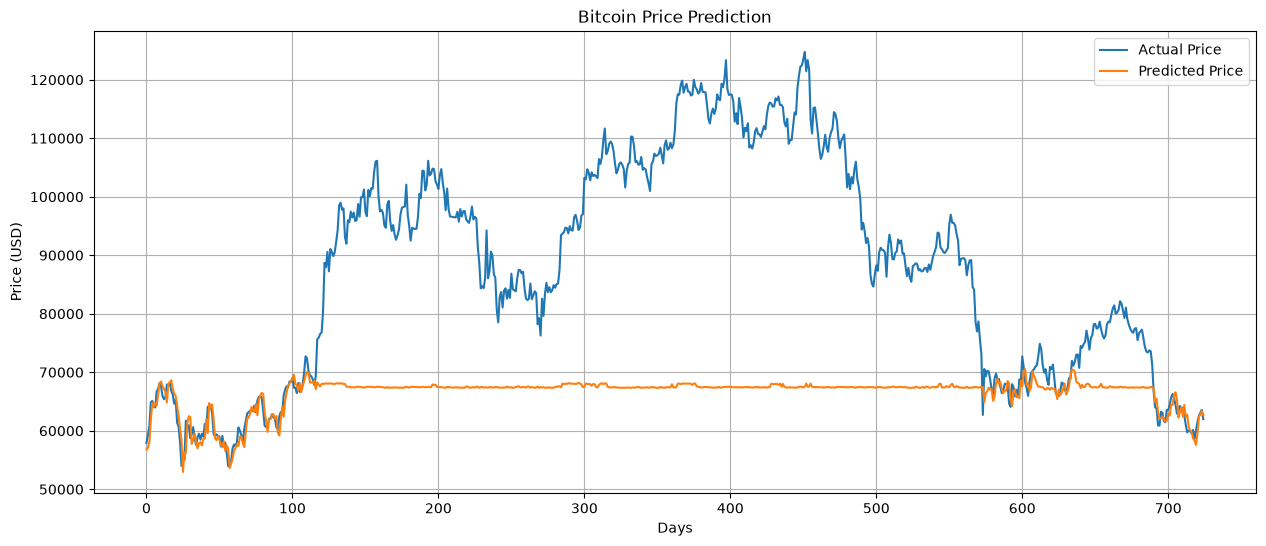

In [12]:
plt.figure(figsize=(15,6))

plt.plot(
    y_test.values,
    label="Actual Price"
)

plt.plot(
    predictions,
    label="Predicted Price"
)

plt.title("Bitcoin Price Prediction")

plt.xlabel("Days")

plt.ylabel("Price (USD)")

plt.legend()

plt.grid(True)

plt.show()

In [13]:
latest_data = X.tail(1)

next_day_price = model.predict(latest_data)

print(f"Predicted Next Day Bitcoin Closing Price: ${next_day_price[0]:,.2f}")

Predicted Next Day Bitcoin Closing Price: $62,716.61
